# Análisis de Sentimientos Básico

En este cuaderno realizaremos un análisis de sentimientos completo utilizando Python. El objetivo es procesar comentarios extraídos de YouTube, clasificarlos como positivos o negativos utilizando un modelo entrenado y visualizar los resultados mediante gráficas y nubes de palabras.

---

## Carga de librerías

In [4]:
from selenium.webdriver import Chrome
from webdriver_manager.chrome import ChromeDriverManager
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
import time
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait

## Descargar datos de una red social

In [5]:
def main():
    service = Service(ChromeDriverManager().install())
    option = webdriver.ChromeOptions()
    #option.add_argument("--headless")
    option.add_argument("--window-size=1920,1080")
    driver = Chrome(service=service, options=option)
    driver.get("https://www.youtube.com/watch?v=Rx3j6PXmT_o&t=736s")

    # Esperar un poco a que cargue la página inicial
    time.sleep(2)

    # YouTube carga comentarios de forma diferida. Necesitamos bajar para que aparezcan.
    # Desplazarse hacia abajo 600 píxeles para que la sección de comentarios se active.
    driver.execute_script("window.scrollTo(0, 600);")
    
    # Usar WebDriverWait para esperar a que aparezca al menos un comentario
    wait = WebDriverWait(driver, 15)
    try:
        # El ID 'content-text' se usa para el texto de cada comentario
        # Esperamos a que el primero sea visible
        wait.until(EC.presence_of_element_located((By.ID, "content-text")))
        
        # Obtener todos los comentarios visibles actualmente
        comments = driver.find_elements(By.ID, "content-text")
    except TimeoutException:
        print("No se encontraron comentarios después de esperar 15 segundos.")

## Carga de datos para clasificar comentarios positivos y negativos

In [6]:
comentarios_positivos = [
    "este video es increible me encanto mucho", "muy buen contenido lo disfrute bastante",
    "excelente explicacion todo quedo claro", "me gusto mucho este video es genial",
    "contenido de gran calidad muy recomendado", "este canal siempre hace videos buenos",
    "me encanto la forma en que explicaste", "super interesante y facil de entender",
    "muy util gracias por compartir", "es un video fantastico lo ame",
    "explicacion clara y muy bien hecha", "me sirvio bastante este contenido",
    "uno de los mejores videos que he visto", "todo esta perfecto excelente trabajo",
    "muy buen video sigue asi", "aprendi mucho con este video",
    "contenido muy valioso y bien explicado", "me dejo impresionado muy buen trabajo",
    "es realmente interesante y entretenido", "gran video me gusto demasiado",
    "todo muy bien explicado y claro", "excelente contenido muy profesional",
    "este video es simplemente genial", "muy buena calidad de informacion",
    "me encanto lo volvere a ver", "es un contenido muy bien hecho",
    "me parecio muy interesante y util", "video increible muy recomendado",
    "explicacion sencilla y efectiva", "gran trabajo sigue subiendo contenido asi"
]

comentarios_negativos = [
    "este video es horrible no me gusto", "muy mal contenido no sirve",
    "explicacion terrible no se entiende", "es una perdida de tiempo",
    "contenido aburrido y mal hecho", "no me gusto para nada este video",
    "muy mala calidad de informacion", "explicacion confusa y desordenada",
    "es un video muy malo", "no aporta nada es inutil",
    "me decepciono bastante este contenido", "muy aburrido casi me duermo",
    "contenido de baja calidad", "no lo recomiendo para nada",
    "explicas muy mal no se entiende", "este video es una basura",
    "muy mal explicado y confuso", "no vale la pena verlo",
    "contenido muy pobre y simple", "me arrepiento de haberlo visto",
    "explicacion pesima y sin sentido", "muy mal video no me gusto",
    "esto es inutil y aburrido", "no tiene nada interesante",
    "contenido muy malo y lento", "explicacion horrible no ayuda",
    "video terrible muy decepcionante", "no cumple con lo que promete",
    "muy mal trabajo no me gusto", "esto es realmente malo"
]

print(f"Datos de entrenamiento cargados: {len(comentarios_positivos)} positivos y {len(comentarios_negativos)} negativos.")

Datos de entrenamiento cargados: 30 positivos y 30 negativos.


## Limpieza de datos

In [7]:
def limpiar_texto(texto):
    # Convertir a minúsculas
    texto = texto.lower()
            
    # Quitar acentos
    texto = unicodedata.normalize('NFD', texto)
    texto = texto.encode('ascii', 'ignore').decode('utf-8')
            
    # Eliminar caracteres especiales (dejar solo letras y espacios)
    texto = re.sub(r'[^a-z\s]', '', texto)
            
    # Eliminar espacios extra
    texto = re.sub(r'\s+', ' ', texto).strip()
            
    return texto
        

## Tokenización y Eliminación de Stopwords

In [9]:
#tokenizacion y eliminacion de stopwords
stop_words = set(stopwords.words('spanish'))

def tokenizar_y_filtrar(texto):
    tokens = word_tokenize(texto)
    filtrados = [word for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(filtrados)

## ANÁLISIS 1 Conteo de Comentarios Positivos vs Negativos

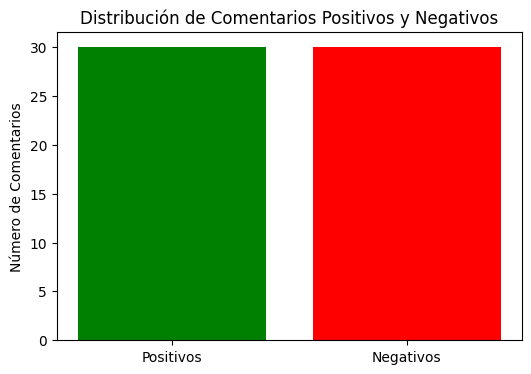

In [10]:
import matplotlib.pyplot as plt

num_positivos = len(comentarios_positivos)
num_negativos = len(comentarios_negativos)

# Crear el gráfico de barras
plt.figure(figsize=(6, 4))
plt.bar(['Positivos', 'Negativos'], [num_positivos, num_negativos], color=['green', 'red'])
plt.title('Distribución de Comentarios Positivos y Negativos')
plt.ylabel('Número de Comentarios')
plt.show()

## ANÁLISIS 2 Conteo de Palabras Más Frecuentes


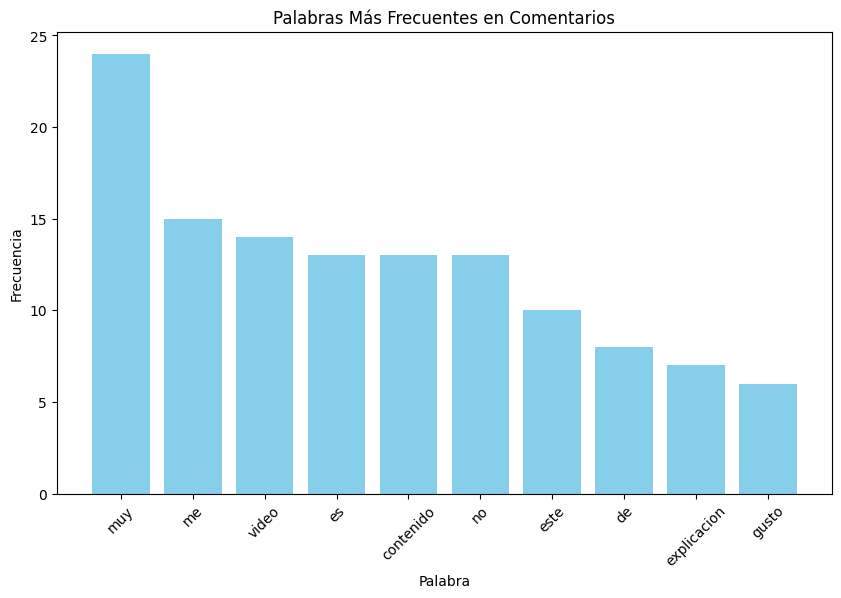

In [11]:
textos_totales = comentarios_positivos + comentarios_negativos
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(textos_totales)

# Obtener las palabras y sus frecuencias
palabras = vectorizer.get_feature_names_out()
frecuencias = X.sum(axis=0).tolist()[0]

    # Crear un DataFrame para visualizar
import pandas as pd
df_frecuencias = pd.DataFrame({'Palabra': palabras, 'Frecuencia': frecuencias})
df_frecuencias = df_frecuencias.sort_values(by='Frecuencia', ascending=False).head(10)

    # Crear el gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(df_frecuencias['Palabra'], df_frecuencias['Frecuencia'], color='skyblue')
plt.title('Palabras Más Frecuentes en Comentarios')
plt.xlabel('Palabra')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

## ANÁLISIS 3Palabras en Comentarios Positivos vs Negativos


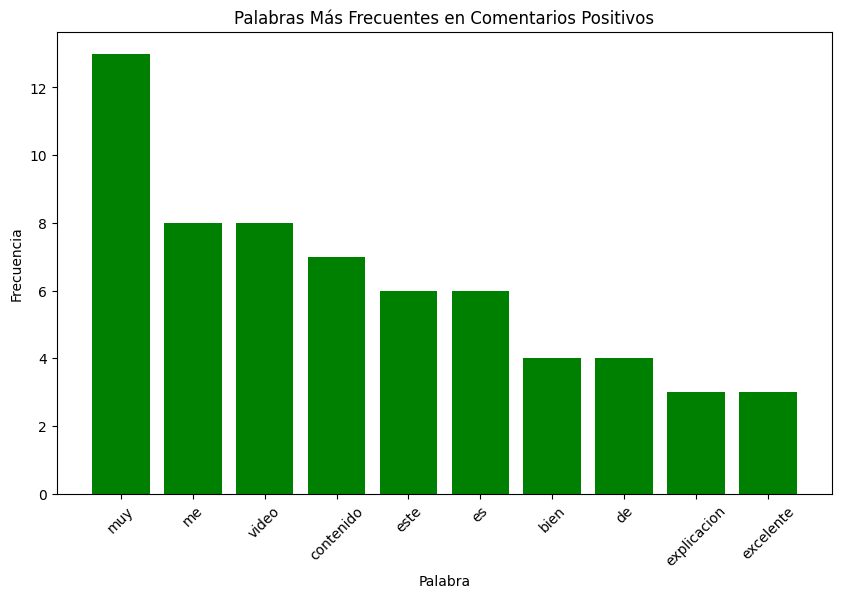

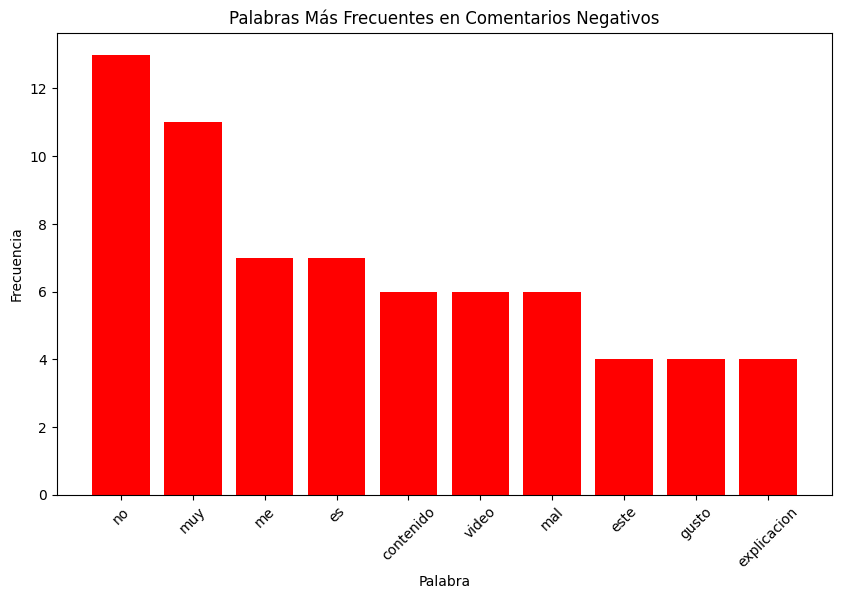

In [12]:
vectorizer_pos = CountVectorizer()
X_pos = vectorizer_pos.fit_transform(comentarios_positivos)
palabras_pos = vectorizer_pos.get_feature_names_out()
frecuencias_pos = X_pos.sum(axis=0).tolist()[0]
vectorizer_neg = CountVectorizer()
X_neg = vectorizer_neg.fit_transform(comentarios_negativos)
palabras_neg = vectorizer_neg.get_feature_names_out()
frecuencias_neg = X_neg.sum(axis=0).tolist()[0]

# Crear un DataFrame para visualizar
df_frecuencias_pos = pd.DataFrame({'Palabra': palabras_pos, 'Frecuencia': frecuencias_pos})
df_frecuencias_pos = df_frecuencias_pos.sort_values(by='Frecuencia', ascending=False).head(10)

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(df_frecuencias_pos['Palabra'], df_frecuencias_pos['Frecuencia'], color='green')
plt.title('Palabras Más Frecuentes en Comentarios Positivos')
plt.xlabel('Palabra')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

# Crear un DataFrame para visualizar
df_frecuencias_neg = pd.DataFrame({'Palabra': palabras_neg, 'Frecuencia': frecuencias_neg})
df_frecuencias_neg = df_frecuencias_neg.sort_values(by='Frecuencia', ascending=False).head(10)

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(df_frecuencias_neg['Palabra'], df_frecuencias_neg['Frecuencia'], color='red')
plt.title('Palabras Más Frecuentes en Comentarios Negativos')
plt.xlabel('Palabra')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()

## ANÁLISIS 4 Nube de Palabras por Sentimiento


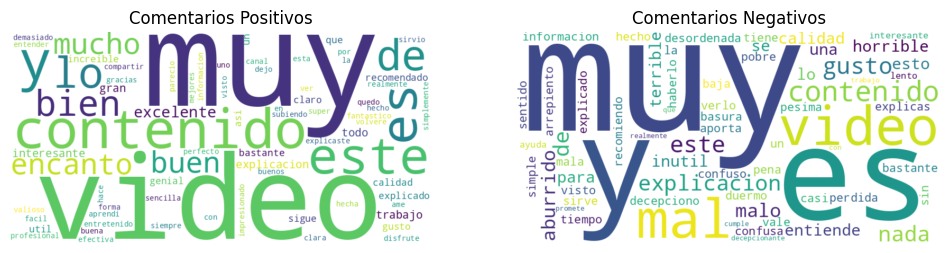

In [13]:
from wordcloud import WordCloud

    # Crear una nube de palabras para comentarios positivos
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(' '.join(comentarios_positivos))

    # Crear una nube de palabras para comentarios negativos
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(' '.join(comentarios_negativos))
    
    # Mostrar las nubes de palabras en subplots
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('Comentarios Positivos')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title('Comentarios Negativos')
plt.axis('off')

plt.show()

## Conclusión

El desarrollo de este sistema permitió construir un flujo completo de análisis de texto, desde la extracción de comentarios hasta su clasificación automática en positivos o negativos. A través del uso de técnicas de procesamiento de lenguaje natural, como la limpieza de texto y la vectorización, se logró transformar datos no estructurados en información que puede ser analizada por un modelo predictivo.

En conclusión, este proyecto cumple con el objetivo de desarrollar un modelo predictivo funcional bajo la metodología CRISP-DM, sentando una base sólida sobre la cual se pueden implementar mejoras futuras para lograr un sistema más robusto y preciso en la detección de sentimientos en comentarios.